### Dependencies

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

### Load Raw Data

In [3]:
# === Load Raw Data ===
ambient_vib_pcb = np.load("ambient_vib_pcb.npy")
ambient_vib_wsn = np.load("ambient_vib_wsn.npy")
free_vib_pcb = np.load("free_vib_pcb.npy")
free_vib_wsn = np.load("free_vib_wsn.npy")

# === Transform Function: Convert PCB to WSN-Aligned Coordinate System ===
def transform_pcb_to_wsn(pcb_data):
    transformed = np.empty_like(pcb_data)
    for sensor_index in range(4):
        base = sensor_index * 3
        pcb_x = pcb_data[:, base + 0]
        pcb_y = pcb_data[:, base + 1]
        pcb_z = pcb_data[:, base + 2]

        # Coordinate transformation:
        # WSN_X = -PCB_Y
        # WSN_Y =  PCB_X
        # WSN_Z =  PCB_Z
        transformed[:, base + 0] = -pcb_y  # WSN X
        transformed[:, base + 1] =  pcb_x  # WSN Y
        transformed[:, base + 2] =  pcb_z  # WSN Z
    return transformed

# === Generate Aligned Versions ===
am_pcb_aligned   = transform_pcb_to_wsn(ambient_vib_pcb)
am_wsn_aligned   = ambient_vib_wsn.copy()

free_pcb_aligned = transform_pcb_to_wsn(free_vib_pcb)
free_wsn_aligned = free_vib_wsn.copy()

# === (Optional) Confirm Shapes Match ===
print("am_pcb_aligned:   ", am_pcb_aligned.shape)
print("am_wsn_aligned:   ", am_wsn_aligned.shape)
print("free_pcb_aligned: ", free_pcb_aligned.shape)
print("free_wsn_aligned: ", free_wsn_aligned.shape)


am_pcb_aligned:    (614400, 12)
am_wsn_aligned:    (41999, 12)
free_pcb_aligned:  (368640, 12)
free_wsn_aligned:  (17999, 12)


### Plot Raw Data

#### - Ambient Vibration

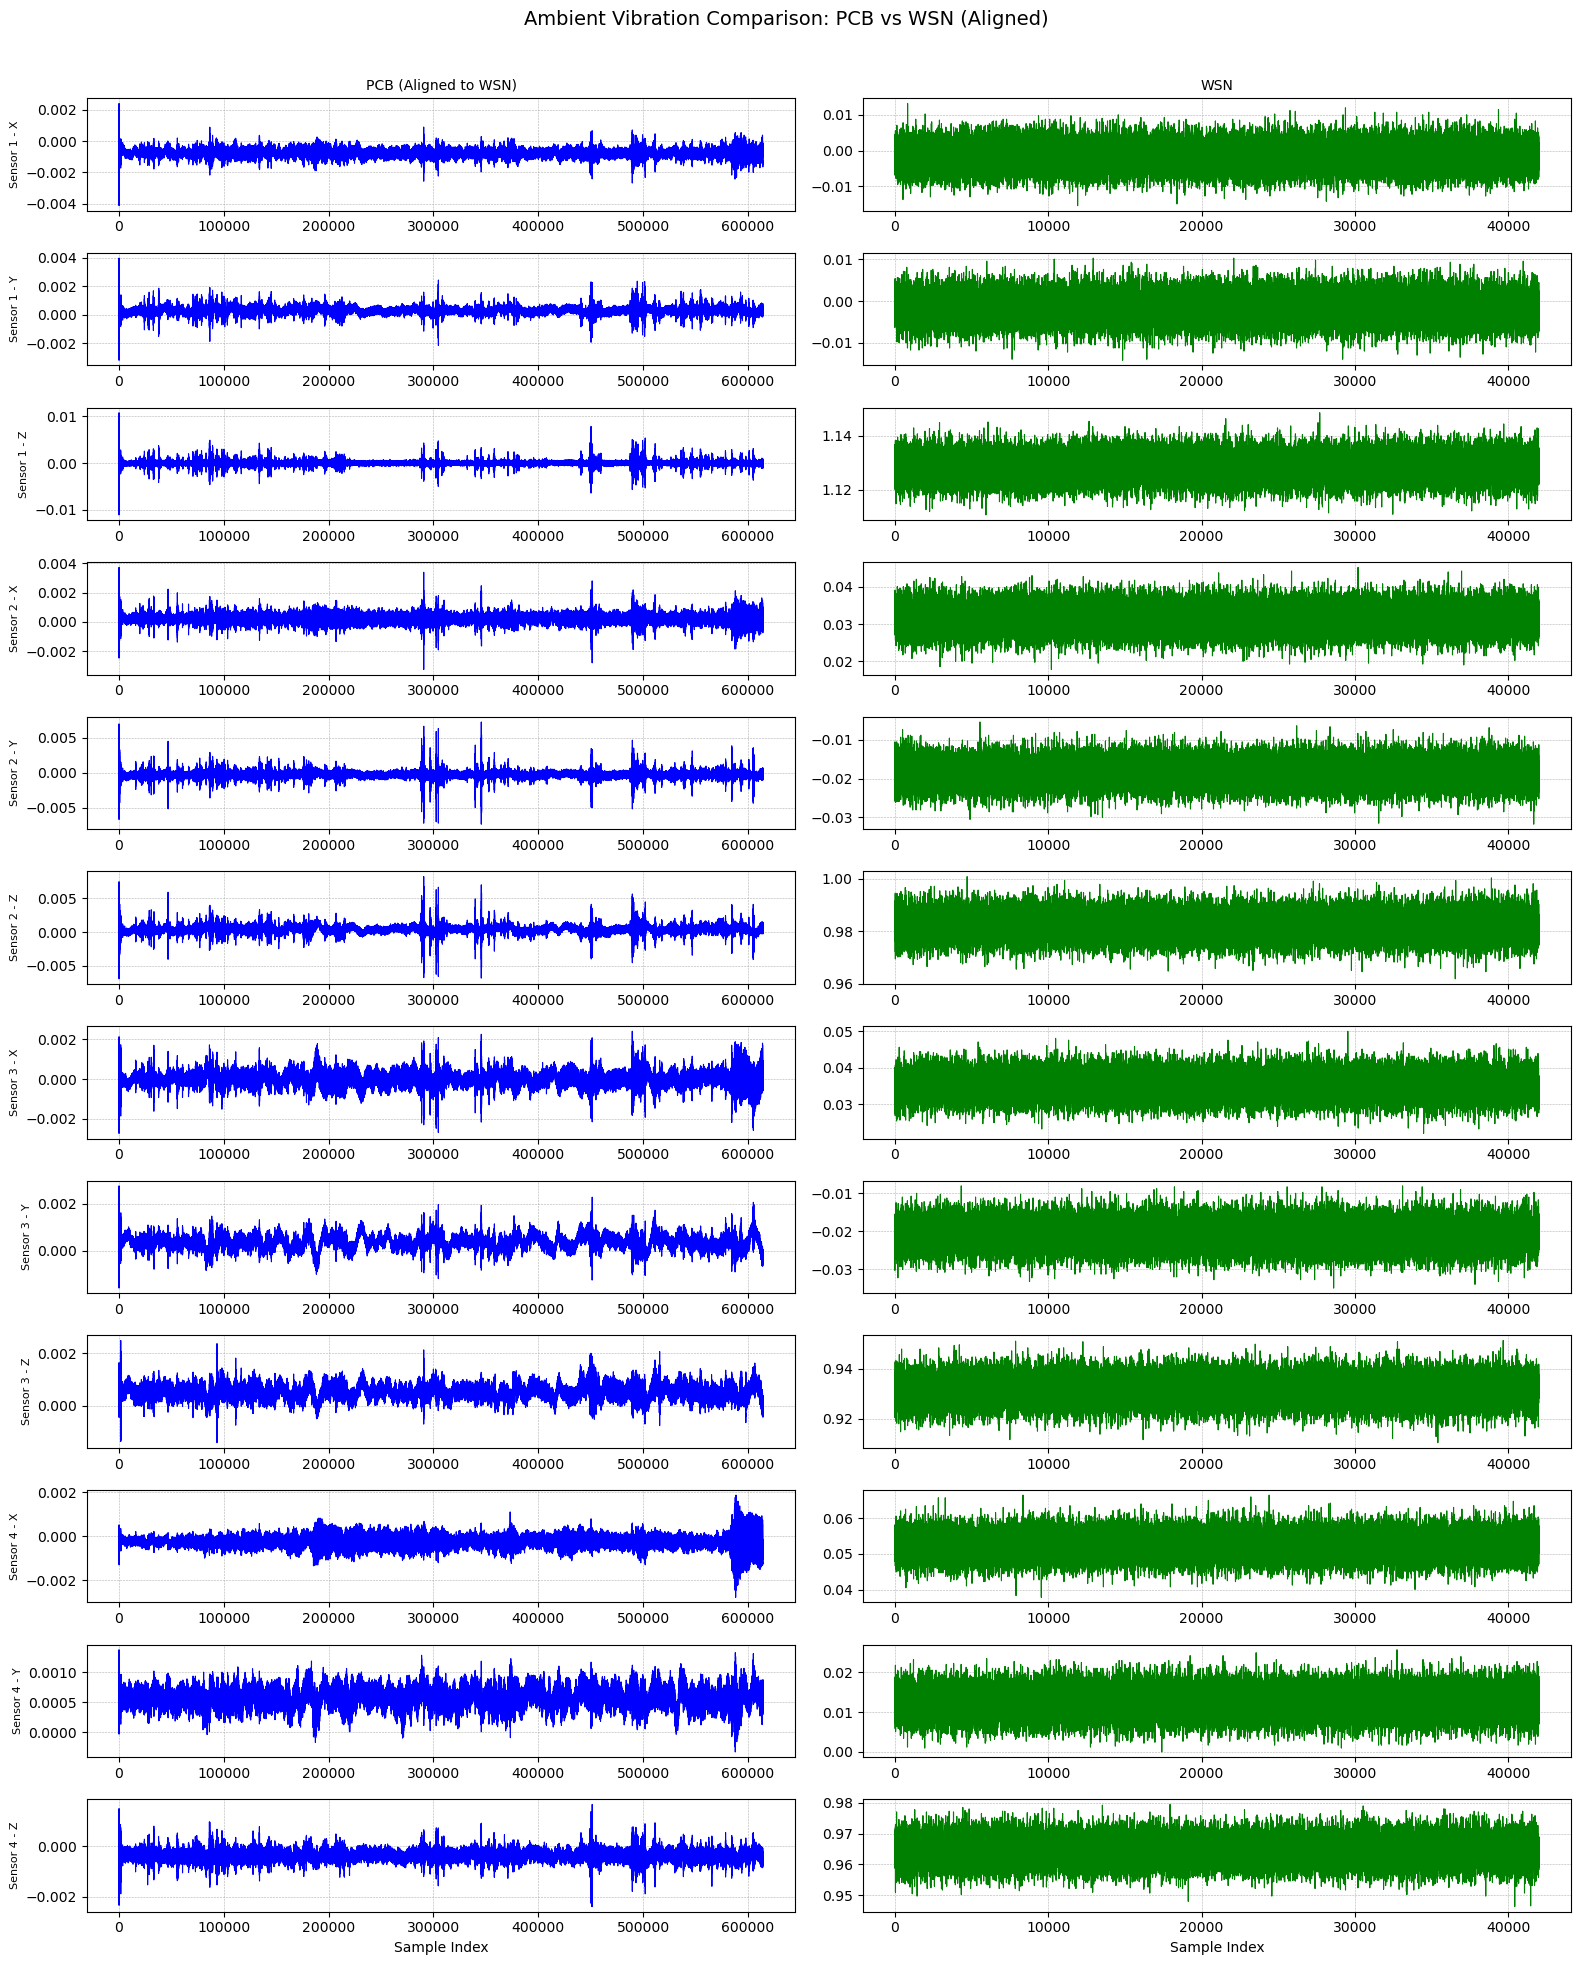

In [4]:
# === Time Axes (independent) ===
time_pcb_am = np.arange(am_pcb_aligned.shape[0])
time_wsn_am = np.arange(am_wsn_aligned.shape[0])

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot ===
fig, axes = plt.subplots(12, 2, figsize=(16, 20), sharex=False)

for i in range(12):
    # Left: PCB (Aligned)
    axes[i, 0].plot(time_pcb_am, am_pcb_aligned[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB (Aligned to WSN)", fontsize=10)

    # Right: WSN
    axes[i, 1].plot(time_wsn_am, am_wsn_aligned[:, i], color='green', linewidth=0.8)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Ambient Vibration Comparison: PCB vs WSN (Aligned)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#### - Free Vibration

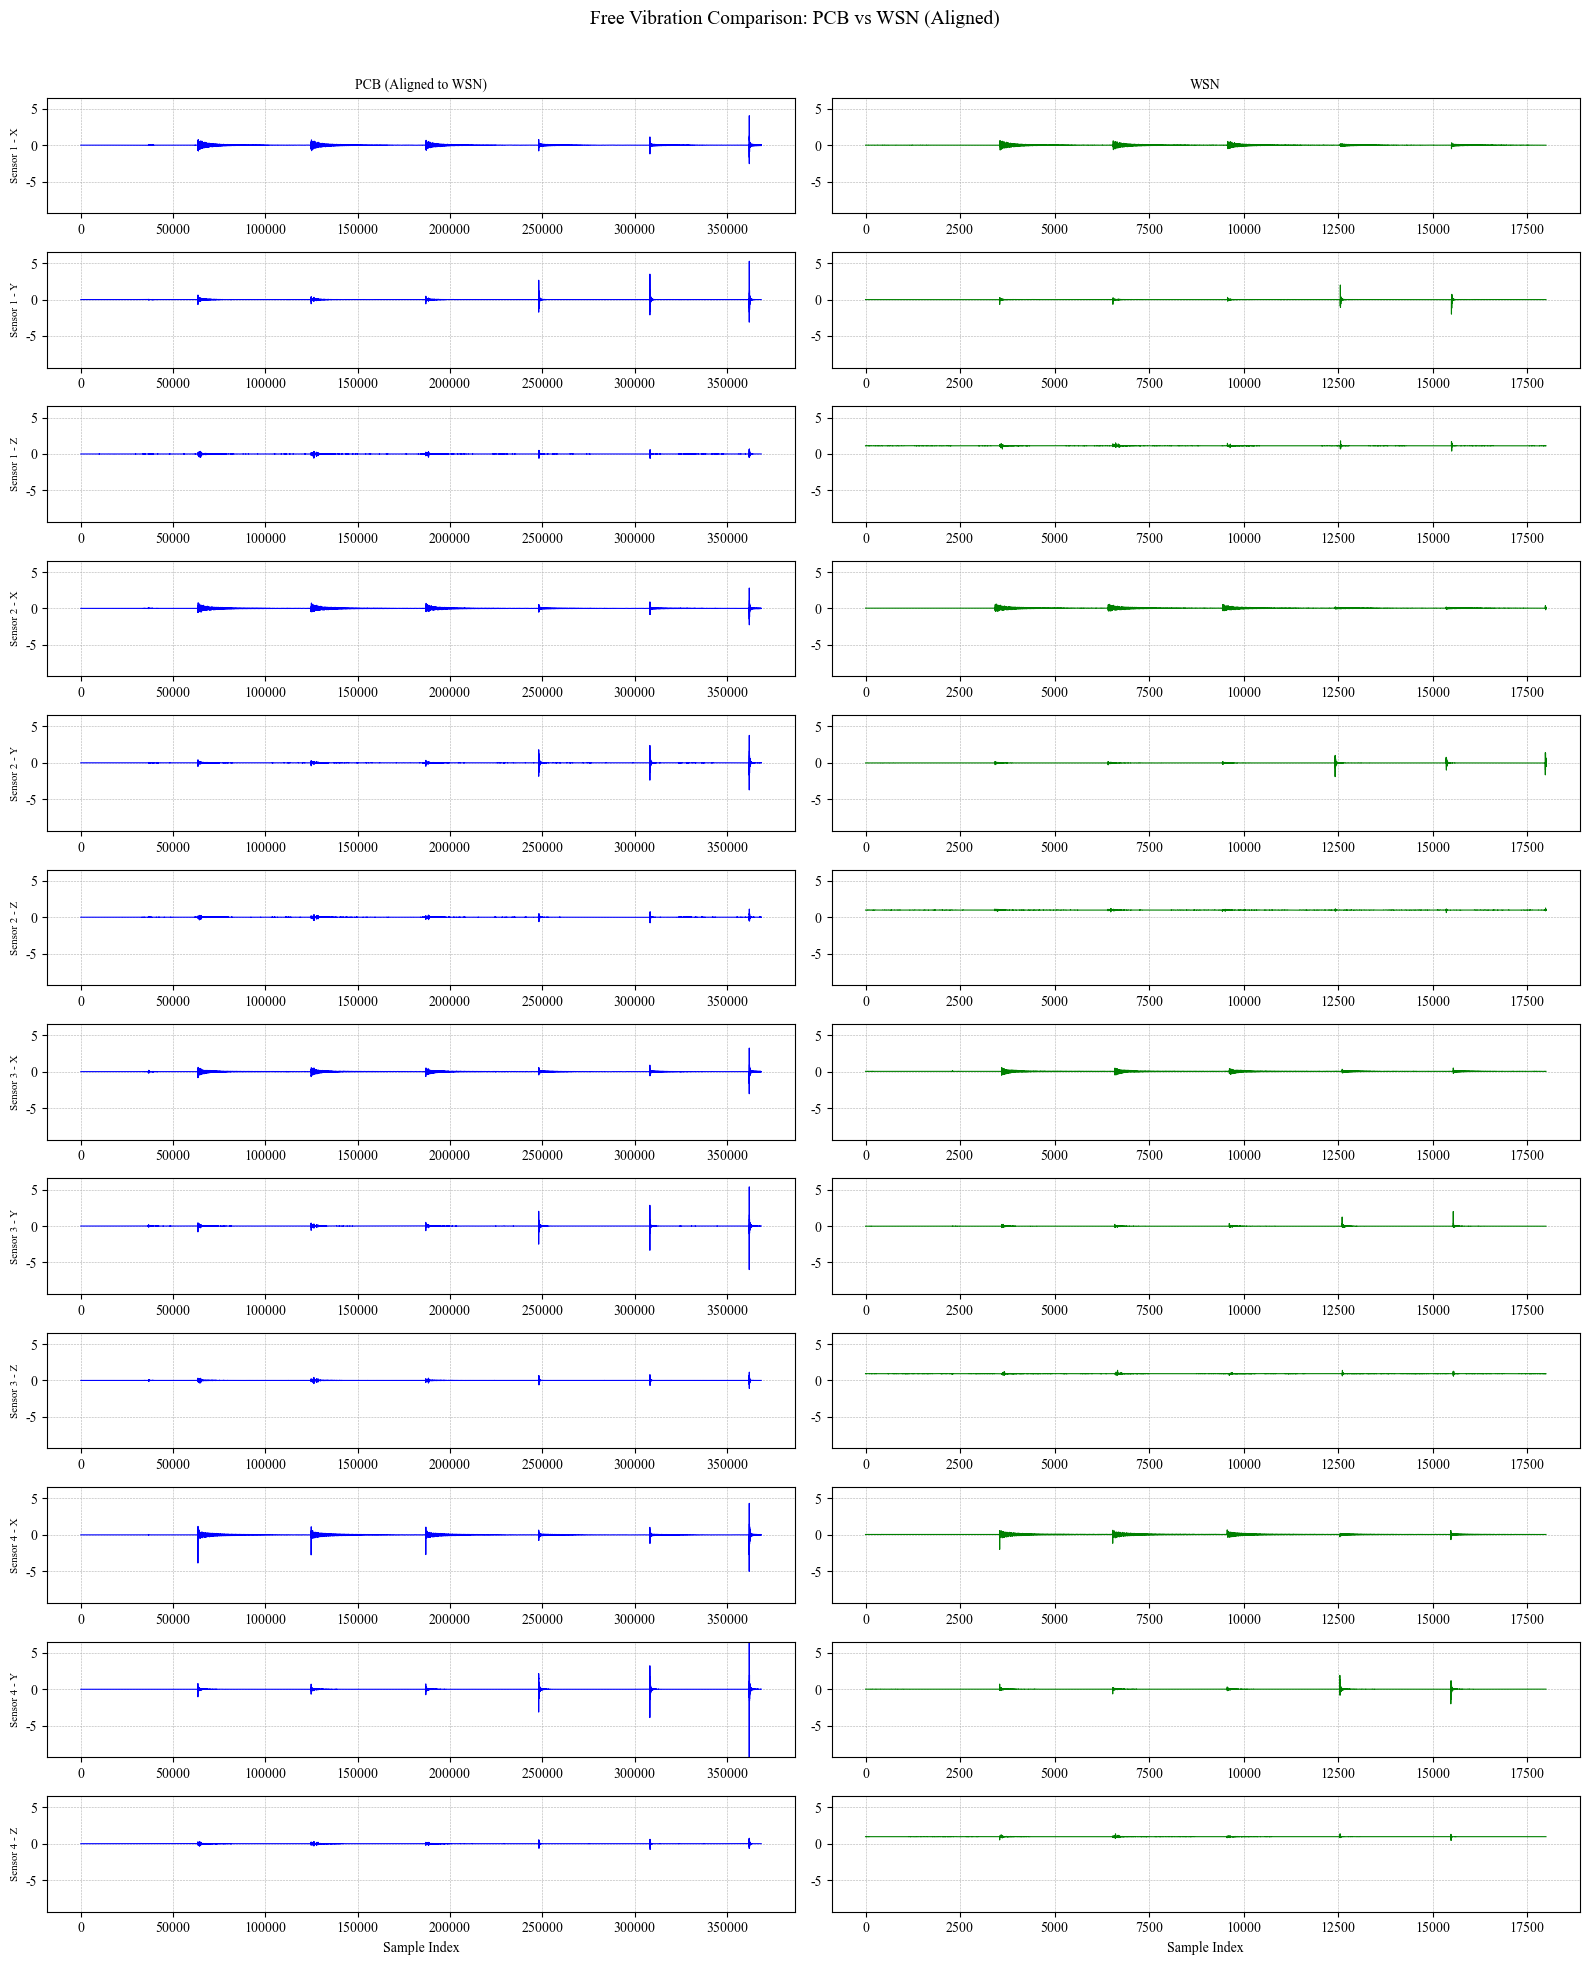

In [5]:
# === Font Settings ===
rcParams['font.family'] = 'Times New Roman'
rcParams['axes.unicode_minus'] = False

# === Time Axes (independent) ===
time_pcb = np.arange(free_pcb_aligned.shape[0])
time_wsn = np.arange(free_wsn_aligned.shape[0])

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Global Y Axis Range for Consistency ===
y_min = min(free_pcb_aligned.min(), free_wsn_aligned.min())
y_max = max(free_pcb_aligned.max(), free_wsn_aligned.max())

# === Plot ===
fig, axes = plt.subplots(12, 2, figsize=(16, 20), sharex=False)

for i in range(12):
    # Left: PCB
    axes[i, 0].plot(time_pcb, free_pcb_aligned[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].set_ylim(y_min, y_max)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB (Aligned to WSN)", fontsize=10)

    # Right: WSN
    axes[i, 1].plot(time_wsn, free_wsn_aligned[:, i], color='green', linewidth=0.8)
    axes[i, 1].set_ylim(y_min, y_max)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Free Vibration Comparison: PCB vs WSN (Aligned)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Data Processing - Detrending and Demeaning

In [6]:
from scipy.signal import detrend

def preprocess(data):
    """
    Preprocess data by:
    1. Removing linear trend.
    2. Removing column-wise mean.
    """
    data_detrended = detrend(data, axis=0)
    data_zero_mean = data_detrended - np.mean(data_detrended, axis=0)
    return data_zero_mean


In [7]:
am_pcb_processed   = preprocess(am_pcb_aligned)
am_wsn_processed   = preprocess(am_wsn_aligned)
free_pcb_processed = preprocess(free_pcb_aligned)
free_wsn_processed = preprocess(free_wsn_aligned)

print("Processed Ambient PCB Shape:   ", am_pcb_processed.shape)
print("Processed Ambient WSN Shape:   ", am_wsn_processed.shape)
print("Processed Free PCB Shape:     ", free_pcb_processed.shape)
print("Processed Free WSN Shape:     ", free_wsn_processed.shape)


Processed Ambient PCB Shape:    (614400, 12)
Processed Ambient WSN Shape:    (41999, 12)
Processed Free PCB Shape:      (368640, 12)
Processed Free WSN Shape:      (17999, 12)


In [8]:
from scipy.signal import resample_poly

def downsample_signal(signal, orig_fs, target_fs):
    """
    Downsample a multi-channel signal to target_fs using polyphase filtering.
    
    Parameters:
        signal     : np.ndarray of shape (N, C) - N samples, C channels
        orig_fs    : original sampling frequency
        target_fs  : target sampling frequency (must be lower than orig_fs)
        
    Returns:
        np.ndarray of shape (M, C) - downsampled signal
    """
    if target_fs >= orig_fs:
        raise ValueError("Target sampling frequency must be less than original sampling frequency.")

    # Compute integer factors
    from math import gcd
    g = gcd(orig_fs, target_fs)
    up = target_fs // g
    down = orig_fs // g

    # Apply resample_poly on each column
    channels = []
    for i in range(signal.shape[1]):
        ch = resample_poly(signal[:, i], up, down)
        channels.append(ch)

    # Stack back to array
    return np.stack(channels, axis=1)


In [9]:
# Sampling rates
FS_PCB = 2048
FS_WSN = 100

# Apply downsampling
am_pcb_downsampled   = downsample_signal(am_pcb_processed, FS_PCB, FS_WSN)
free_pcb_downsampled = downsample_signal(free_pcb_processed, FS_PCB, FS_WSN)

# Check shapes
print("Downsampled Ambient PCB shape:", am_pcb_downsampled.shape)
print("Downsampled Free PCB shape:", free_pcb_downsampled.shape)


Downsampled Ambient PCB shape: (30000, 12)
Downsampled Free PCB shape: (18000, 12)


In [10]:
def normalize_signal(signal):
    """
    Normalize each column (channel) using Z-score normalization.
    Output has zero mean and unit variance per channel.
    """
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)
    std[std == 0] = 1  # avoid division by zero
    return (signal - mean) / std


In [11]:
# normalize the data before time sync

am_pcb_normalized   = normalize_signal(am_pcb_downsampled)
am_wsn_normalized   = normalize_signal(am_wsn_processed)
free_pcb_normalized = normalize_signal(free_pcb_downsampled)
free_wsn_normalized = normalize_signal(free_wsn_processed)

# check shapes
print("Normalized Ambient PCB shape:", am_pcb_normalized.shape)
print("Normalized Ambient WSN shape:", am_wsn_normalized.shape)
print("Normalized Free PCB shape:", free_pcb_normalized.shape)
print("Normalized Free WSN shape:", free_wsn_normalized.shape)


Normalized Ambient PCB shape: (30000, 12)
Normalized Ambient WSN shape: (41999, 12)
Normalized Free PCB shape: (18000, 12)
Normalized Free WSN shape: (17999, 12)


### TIME DOMAIN ANALYSES

#### - Time Lags

In [12]:
from scipy.signal import correlate

def compute_lag(x, y, fs):
    """
    Compute lag (in seconds) between two signals using cross-correlation.
    Positive lag means y lags behind x.
    """
    corr = correlate(y, x, mode='full')  # y relative to x
    lag_samples = np.argmax(corr) - (len(x) - 1)
    lag_time = lag_samples / fs
    return lag_time, lag_samples, corr

# Constants
FS = 100
duration_sec = 50
samples = FS * duration_sec
target_channels = [0, 3, 6, 9]  # X-axis of each sensor

lags_sec = []
lags_samples = []

for ch in target_channels:
    wsn_segment = free_wsn_normalized[:samples, ch]
    pcb_segment = free_pcb_normalized[:samples, ch]
    
    lag_time, lag_sample, _ = compute_lag(pcb_segment, wsn_segment, FS)
    
    lags_sec.append(lag_time)
    lags_samples.append(lag_sample)
    print(f"Channel {ch:>2} | Lag: {lag_time:>7.3f} sec ({lag_sample:>4} samples)")

# Optional: wrap as array
lags_sec = np.array(lags_sec)
lags_samples = np.array(lags_samples)


Channel  0 | Lag:   4.500 sec ( 450 samples)
Channel  3 | Lag:   3.250 sec ( 325 samples)
Channel  6 | Lag:   5.000 sec ( 500 samples)
Channel  9 | Lag:   4.500 sec ( 450 samples)


#### - Time History Plot

In [13]:
# import matplotlib.pyplot as plt
# import numpy as np

# # === Constants ===
# FS = 100                     # Sampling frequency (Hz)
# MAX_DURATION_SEC = 180       # Max duration to plot (seconds)
# MAX_SAMPLES = FS * MAX_DURATION_SEC

# # === Font Sizes ===
# TITLE_FONT_SIZE = 16
# LABEL_FONT_SIZE = 14
# LEGEND_FONT_SIZE = 12
# TICK_FONT_SIZE = 12

# # === Target channels: X-axis of each sensor ===
# target_channels = [0, 3, 6, 9]
# sensor_labels = ["Sensor 1 - X", "Sensor 2 - X", "Sensor 3 - X", "Sensor 4 - X"]

# fig, axes = plt.subplots(4, 1, figsize=(16, 6), sharex=True)

# for idx, ch in enumerate(target_channels):
#     lag = lags_samples[idx]

#     # Full 180s PCB as reference
#     pcb_aligned = free_pcb_normalized[:MAX_SAMPLES, ch]

#     # Handle WSN with lag compensation
#     if lag > 0:
#         # WSN started later, shift right
#         if lag + MAX_SAMPLES <= len(free_wsn_normalized):
#             wsn_aligned = free_wsn_normalized[lag:lag + MAX_SAMPLES, ch]
#         else:
#             # Not enough WSN data → pad the tail with zeros
#             wsn_part = free_wsn_normalized[lag:, ch]
#             pad_len = MAX_SAMPLES - len(wsn_part)
#             wsn_aligned = np.pad(wsn_part, (0, pad_len), mode='constant')
#     elif lag < 0:
#         # WSN started earlier → shift left, pad front
#         wsn_part = free_wsn_normalized[:MAX_SAMPLES + lag, ch]  # lag is negative
#         wsn_aligned = np.pad(wsn_part, (abs(lag), 0), mode='constant')
#     else:
#         # Aligned
#         wsn_aligned = free_wsn_normalized[:MAX_SAMPLES, ch]

#     # Time axis: fixed 0–180s
#     time = np.arange(MAX_SAMPLES) / FS

#     # Plot
#     axes[idx].plot(time, pcb_aligned, label='PCB', color='blue', linewidth=0.8)
#     axes[idx].plot(time, wsn_aligned, label='WSN (shifted)', color='green', linewidth=0.8, linestyle='--')
#     axes[idx].set_ylabel(sensor_labels[idx], fontsize=LABEL_FONT_SIZE)
#     axes[idx].set_xlim(0, MAX_DURATION_SEC)
#     axes[idx].legend(loc='upper left', fontsize=LEGEND_FONT_SIZE)
#     axes[idx].tick_params(axis='both', labelsize=TICK_FONT_SIZE)
#     axes[idx].grid(True, linestyle='--', linewidth=0.4)

# # X-label and title
# axes[-1].set_xlabel("Time (s)", fontsize=LABEL_FONT_SIZE)
# fig.suptitle("Free Vibration Comparison: Time-Aligned PCB vs WSN", fontsize=TITLE_FONT_SIZE)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("free_vibration_hist_comparison.png", dpi=600, bbox_inches='tight')
# plt.show()


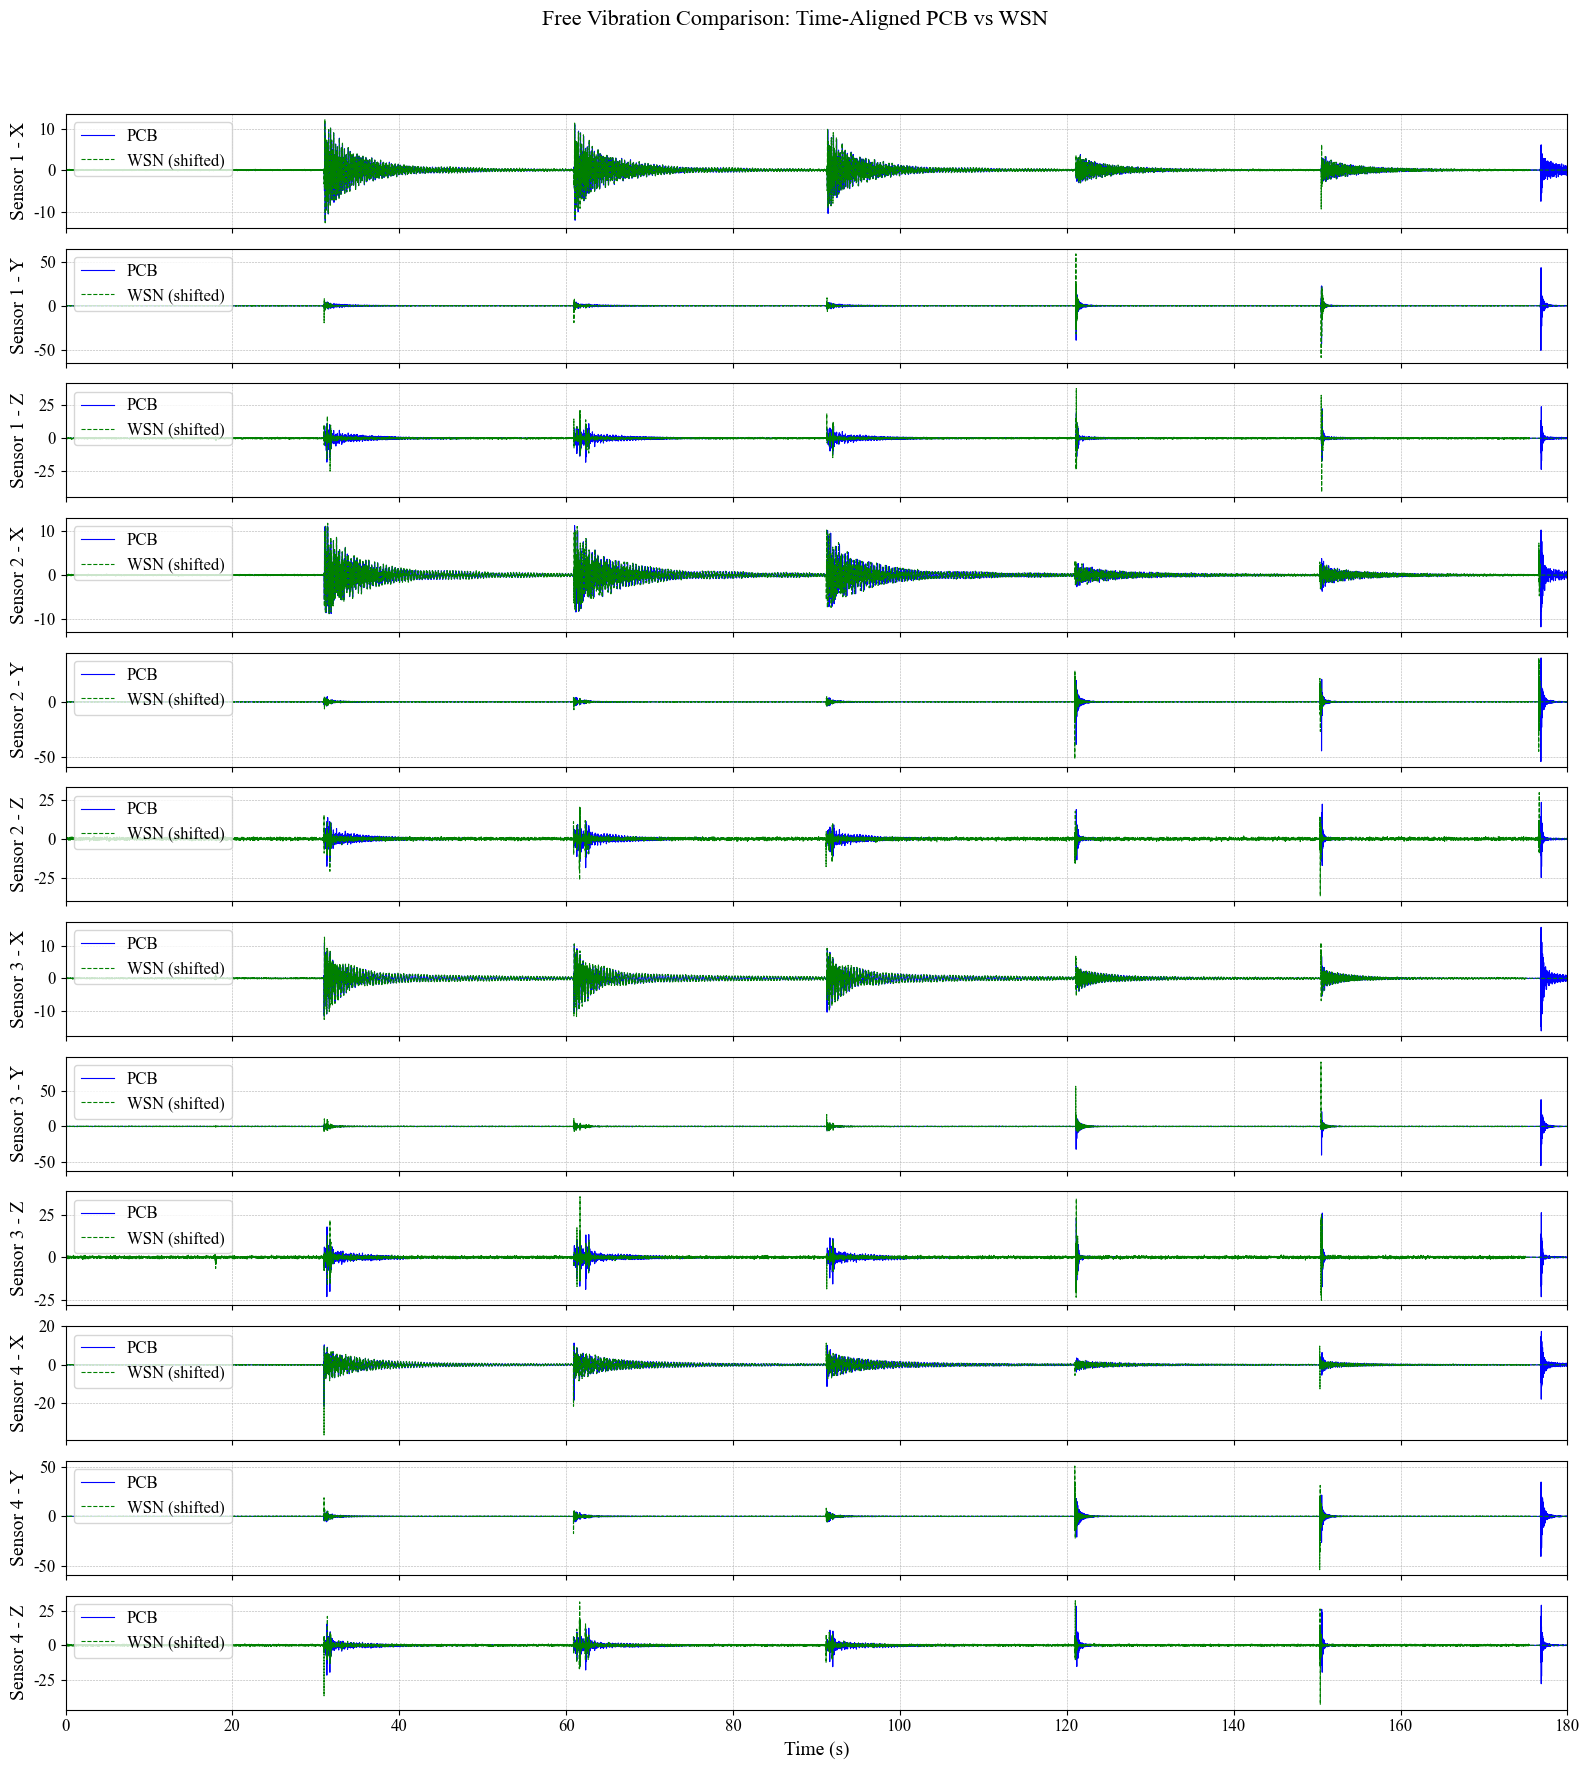

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# === Constants ===
FS = 100
MAX_DURATION_SEC = 180
MAX_SAMPLES = FS * MAX_DURATION_SEC

# === Font Sizes ===
TITLE_FONT_SIZE = 16
LABEL_FONT_SIZE = 14
LEGEND_FONT_SIZE = 12
TICK_FONT_SIZE = 12

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

fig, axes = plt.subplots(12, 1, figsize=(16, 18), sharex=True)

for ch in range(12):
    sensor_idx = ch // 3  # 0 for Sensor 1, 1 for Sensor 2, etc.
    lag = lags_samples[sensor_idx]

    # Full 180s PCB as reference
    pcb_aligned = free_pcb_normalized[:MAX_SAMPLES, ch]

    # Apply delay to WSN
    if lag > 0:
        if lag + MAX_SAMPLES <= len(free_wsn_normalized):
            wsn_aligned = free_wsn_normalized[lag:lag + MAX_SAMPLES, ch]
        else:
            wsn_part = free_wsn_normalized[lag:, ch]
            pad_len = MAX_SAMPLES - len(wsn_part)
            wsn_aligned = np.pad(wsn_part, (0, pad_len), mode='constant')
    elif lag < 0:
        wsn_part = free_wsn_normalized[:MAX_SAMPLES + lag, ch]
        wsn_aligned = np.pad(wsn_part, (abs(lag), 0), mode='constant')
    else:
        wsn_aligned = free_wsn_normalized[:MAX_SAMPLES, ch]

    # Time axis
    time = np.arange(MAX_SAMPLES) / FS

    # Plot
    axes[ch].plot(time, pcb_aligned, label='PCB', color='blue', linewidth=0.8)
    axes[ch].plot(time, wsn_aligned, label='WSN (shifted)', color='green', linewidth=0.8, linestyle='--')
    axes[ch].set_ylabel(channel_labels[ch], fontsize=LABEL_FONT_SIZE)
    axes[ch].set_xlim(0, MAX_DURATION_SEC)
    axes[ch].legend(loc='upper left', fontsize=LEGEND_FONT_SIZE)
    axes[ch].tick_params(axis='both', labelsize=TICK_FONT_SIZE)
    axes[ch].grid(True, linestyle='--', linewidth=0.4)

# Final x-axis and title
axes[-1].set_xlabel("Time (s)", fontsize=LABEL_FONT_SIZE)
fig.suptitle("Free Vibration Comparison: Time-Aligned PCB vs WSN", fontsize=TITLE_FONT_SIZE)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("free_vibration_hist_comparison.png", dpi=600, bbox_inches='tight')
plt.show()


### FREQUENCY DOMAIN ANALYSES

#### - Respective Check

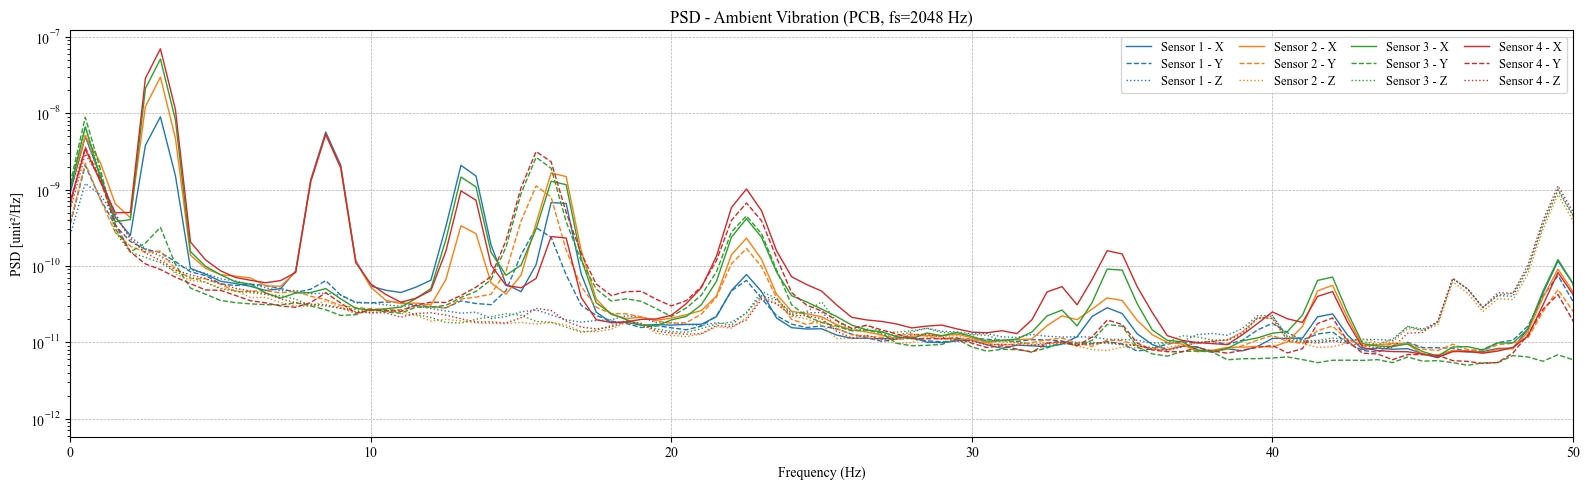

In [55]:
import matplotlib.pyplot as plt
from scipy.signal import welch

fs_pcb = 2048
plt.figure(figsize=(16, 5))

color_list = plt.get_cmap('tab10').colors[:4]
linestyles = ['-', '--', ':']  # X, Y, Z

for ch in range(12):
    sensor_idx = ch // 3
    axis_idx = ch % 3

    f, Pxx = welch(am_pcb_processed[:, ch], fs=fs_pcb, nperseg=4096)
    plt.semilogy(
        f, Pxx,
        label=f'Sensor {sensor_idx+1} - {"XYZ"[axis_idx]}',
        color=color_list[sensor_idx],
        linestyle=linestyles[axis_idx],
        linewidth=1.0
    )

plt.title("PSD - Ambient Vibration (PCB, fs=2048 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD [unit²/Hz]")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xlim(0, 50)

# Legend inside figure area, arranged by sensor column
plt.legend(
    loc='upper right',
    ncol=4,                # 4 columns = 4 sensors
    fontsize=9,
    columnspacing=1.2,
    labelspacing=0.4,
    handlelength=2.0
)

plt.tight_layout(rect=[0, 0, 1, 1])  # ensure room inside plot
plt.show()


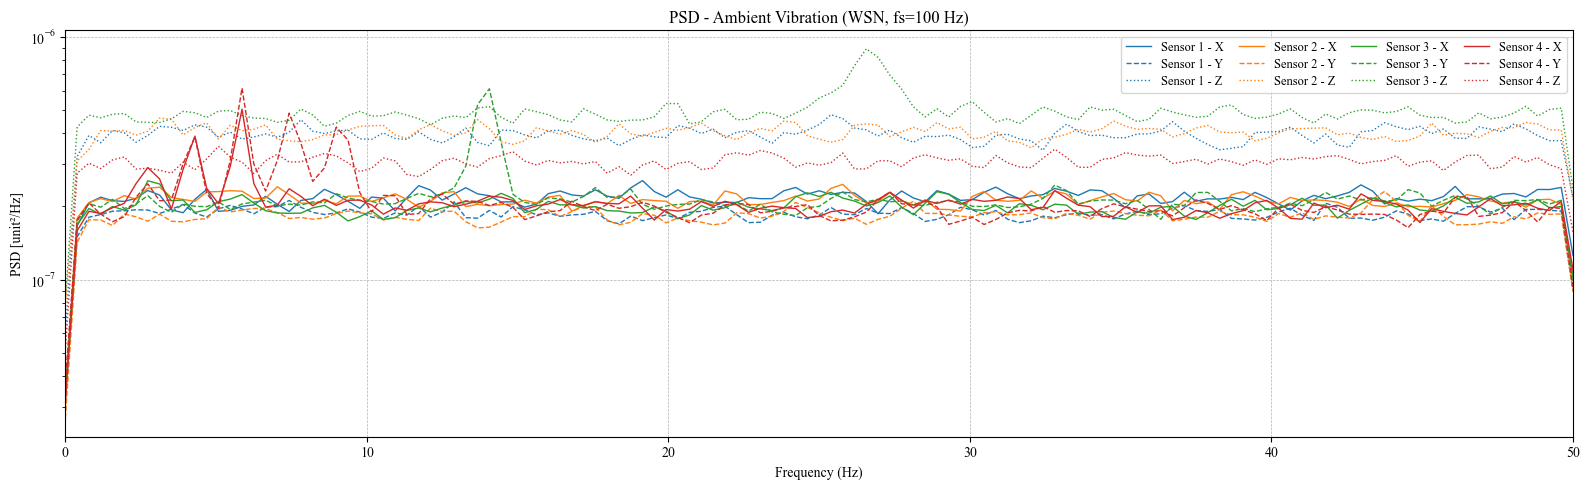

In [25]:
import matplotlib.pyplot as plt
from scipy.signal import welch

fs_wsn = 100  # WSN sampling frequency
plt.figure(figsize=(16, 5))

color_list = plt.get_cmap('tab10').colors[:4]
linestyles = ['-', '--', ':']  # X, Y, Z

for ch in range(12):
    sensor_idx = ch // 3
    axis_idx = ch % 3

    f, Pxx = welch(am_wsn_processed[:, ch], fs=fs_wsn, nperseg=256)
    plt.semilogy(
        f, Pxx,
        label=f'Sensor {sensor_idx+1} - {"XYZ"[axis_idx]}',
        color=color_list[sensor_idx],
        linestyle=linestyles[axis_idx],
        linewidth=1.0
    )

plt.title("PSD - Ambient Vibration (WSN, fs=100 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD [unit²/Hz]")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xlim(0, 50)

# Legend inside figure area, arranged by sensor column
plt.legend(
    loc='upper right',
    ncol=4,                # 4 columns = 4 sensors
    fontsize=9,
    columnspacing=1.2,
    labelspacing=0.4,
    handlelength=2.0
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


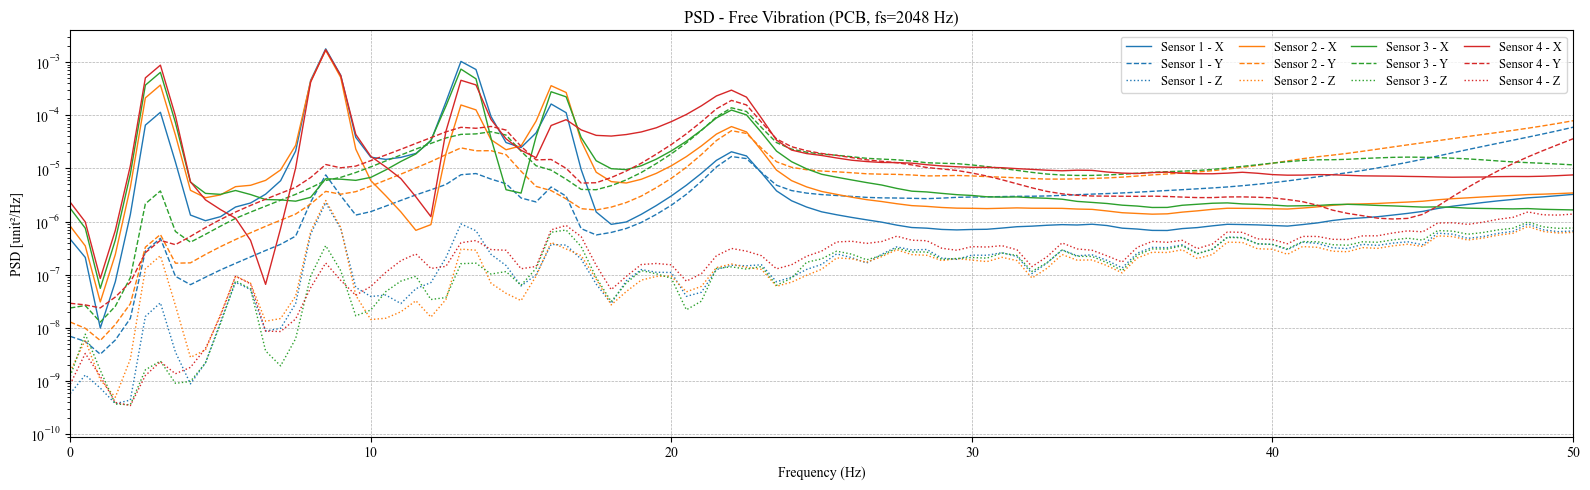

In [26]:
import matplotlib.pyplot as plt
from scipy.signal import welch

fs_pcb = 2048  # PCB sampling frequency
plt.figure(figsize=(16, 5))

color_list = plt.get_cmap('tab10').colors[:4]
linestyles = ['-', '--', ':']  # X, Y, Z

for ch in range(12):
    sensor_idx = ch // 3
    axis_idx = ch % 3

    f, Pxx = welch(free_pcb_processed[:, ch], fs=fs_pcb, nperseg=4096)
    plt.semilogy(
        f, Pxx,
        label=f'Sensor {sensor_idx+1} - {"XYZ"[axis_idx]}',
        color=color_list[sensor_idx],
        linestyle=linestyles[axis_idx],
        linewidth=1.0
    )

plt.title("PSD - Free Vibration (PCB, fs=2048 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD [unit²/Hz]")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xlim(0, 50)

# Legend inside figure area, arranged by sensor column
plt.legend(
    loc='upper right',
    ncol=4,
    fontsize=9,
    columnspacing=1.2,
    labelspacing=0.4,
    handlelength=2.0
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


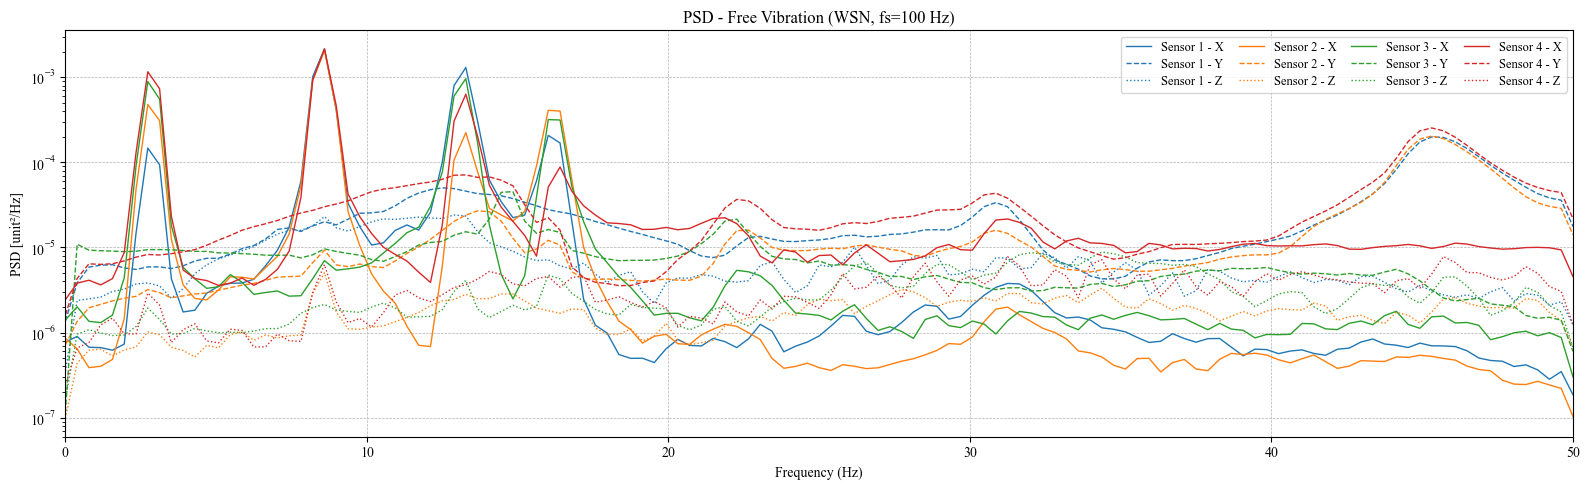

In [31]:
import matplotlib.pyplot as plt
from scipy.signal import welch

fs_wsn = 100  # WSN sampling frequency
plt.figure(figsize=(16, 5))

color_list = plt.get_cmap('tab10').colors[:4]
linestyles = ['-', '--', ':']  # X, Y, Z

for ch in range(12):
    sensor_idx = ch // 3
    axis_idx = ch % 3

    f, Pxx = welch(free_wsn_processed[:, ch], fs=fs_wsn, nperseg=256)
    plt.semilogy(
        f, Pxx,
        label=f'Sensor {sensor_idx+1} - {"XYZ"[axis_idx]}',
        color=color_list[sensor_idx],
        linestyle=linestyles[axis_idx],
        linewidth=1.0
    )

plt.title("PSD - Free Vibration (WSN, fs=100 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD [unit²/Hz]")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xlim(0, 50)

# Legend inside figure area, arranged by sensor column
plt.legend(
    loc='upper right',
    ncol=4,
    fontsize=9,
    columnspacing=1.2,
    labelspacing=0.4,
    handlelength=2.0
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


#### - Comparison

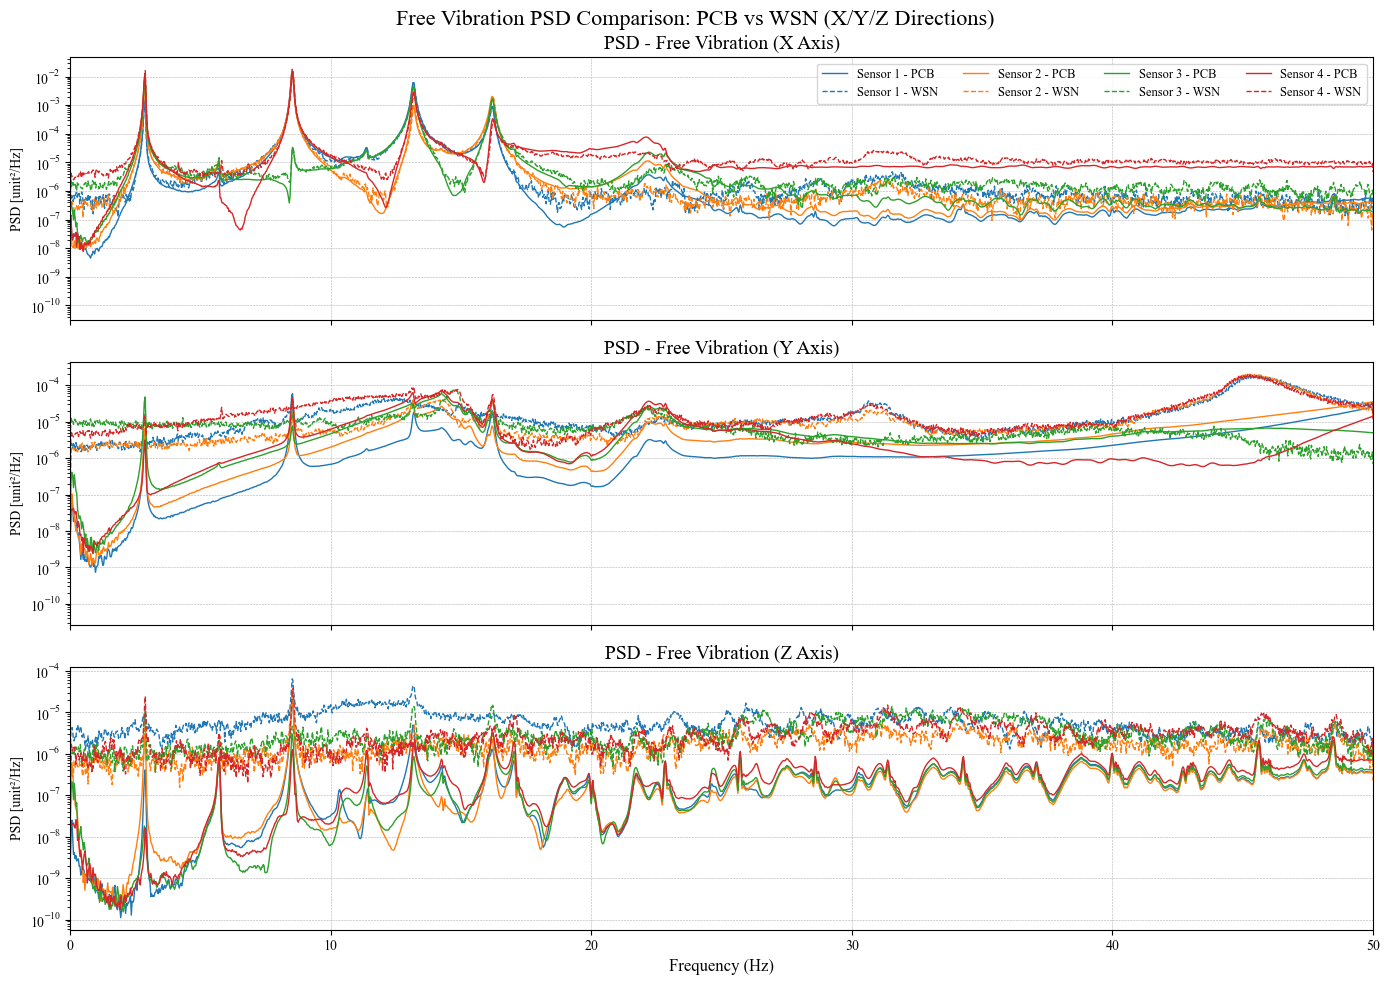

In [53]:
import matplotlib.pyplot as plt
from scipy.signal import welch

fs_pcb = 2048
fs_wsn = 100

color_list = plt.get_cmap('tab10').colors[:4]
axis_labels = ['X', 'Y', 'Z']
linestyles = {'PCB': '-', 'WSN': '--'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for axis_idx, ax in enumerate(axes):
    for sensor_idx in range(4):
        ch = sensor_idx * 3 + axis_idx  # channel index for that axis

        # === PCB PSD ===
        f_pcb, Pxx_pcb = welch(
            free_pcb_processed[:, ch],
            fs=fs_pcb,
            nperseg=65536,
            noverlap=32768,
            window='hamming'
        )
        ax.semilogy(
            f_pcb, Pxx_pcb,
            label=f'Sensor {sensor_idx+1} - PCB',
            color=color_list[sensor_idx],
            linestyle=linestyles['PCB'],
            linewidth=1.0
        )

        # === WSN PSD ===
        f_wsn, Pxx_wsn = welch(
            free_wsn_processed[:, ch],
            fs=fs_wsn,
            nperseg=4096,
            noverlap=2048,
            window='hamming'
        )
        ax.semilogy(
            f_wsn, Pxx_wsn,
            label=f'Sensor {sensor_idx+1} - WSN',
            color=color_list[sensor_idx],
            linestyle=linestyles['WSN'],
            linewidth=1.0
        )

    ax.set_title(f'PSD - Free Vibration ({axis_labels[axis_idx]} Axis)', fontsize=14)
    ax.set_ylabel('PSD [unit²/Hz]')
    ax.grid(True, linestyle='--', linewidth=0.4)
    ax.set_xlim(0, 50)

axes[-1].set_xlabel('Frequency (Hz)', fontsize=12)

# Deduplicated legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), ncol=4, fontsize=9, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Free Vibration PSD Comparison: PCB vs WSN (X/Y/Z Directions)", fontsize=16)
plt.savefig("free_vibration_psd_comparison.png", dpi=600, bbox_inches='tight')
plt.show()


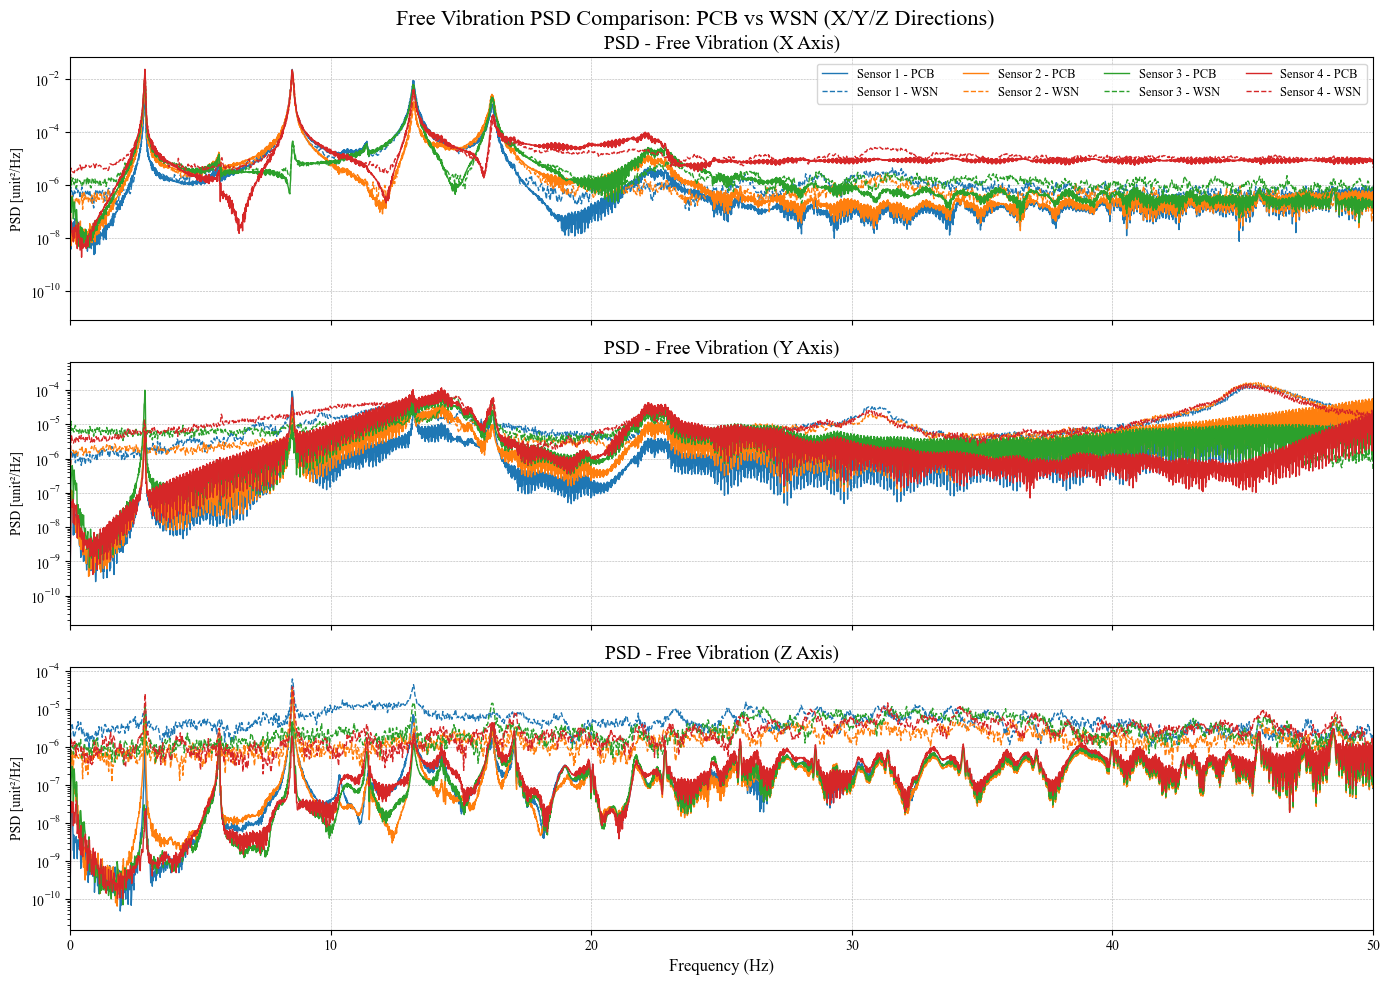

In [38]:
import matplotlib.pyplot as plt
from scipy.signal import welch

fs_pcb = 2048
fs_wsn = 100

color_list = plt.get_cmap('tab10').colors[:4]
axis_labels = ['X', 'Y', 'Z']
linestyles = {'PCB': '-', 'WSN': '--'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for axis_idx, ax in enumerate(axes):
    for sensor_idx in range(4):
        ch = sensor_idx * 3 + axis_idx  # channel index for that axis

        # === PCB PSD ===
        f_pcb, Pxx_pcb = welch(
            free_pcb_processed[:, ch],
            fs=fs_pcb,
            nperseg=136533,
            noverlap=68266,
            window='hamming'
        )
        ax.semilogy(
            f_pcb, Pxx_pcb,
            label=f'Sensor {sensor_idx+1} - PCB',
            color=color_list[sensor_idx],
            linestyle=linestyles['PCB'],
            linewidth=1.0
        )

        # === WSN PSD ===
        f_wsn, Pxx_wsn = welch(
            free_wsn_processed[:, ch],
            fs=fs_wsn,
            nperseg=4000,
            noverlap=2000,
            window='hamming'
        )
        ax.semilogy(
            f_wsn, Pxx_wsn,
            label=f'Sensor {sensor_idx+1} - WSN',
            color=color_list[sensor_idx],
            linestyle=linestyles['WSN'],
            linewidth=1.0
        )

    ax.set_title(f'PSD - Free Vibration ({axis_labels[axis_idx]} Axis)', fontsize=14)
    ax.set_ylabel('PSD [unit²/Hz]')
    ax.grid(True, linestyle='--', linewidth=0.4)
    ax.set_xlim(0, 50)

axes[-1].set_xlabel('Frequency (Hz)', fontsize=12)

# Deduplicated legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), ncol=4, fontsize=9, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Free Vibration PSD Comparison: PCB vs WSN (X/Y/Z Directions)", fontsize=16)
plt.savefig("free_vibration_psd_comparison.png", dpi=600, bbox_inches='tight')
plt.show()


In [47]:
import numpy as np
from scipy.signal import welch, find_peaks
import matplotlib.pyplot as plt

fs_pcb = 2048
fs_wsn = 100
axis_labels = ['X', 'Y', 'Z']
num_sensors = 4
num_modes = 4

# Use larger nperseg to improve frequency resolution
nperseg_pcb = fs_pcb * 8  # previously fs_pcb * 4
nperseg_wsn = fs_wsn * 8  # previously fs_wsn * 4

def extract_modal_frequencies(signal_data, fs, nperseg, label):
    print(f"\n=== Shared Modal Frequencies by Axis ({label}) ===")
    shared_freqs = {}

    for axis_idx, axis in enumerate(axis_labels):
        all_freqs = []

        for sensor_idx in range(num_sensors):
            ch = sensor_idx * 3 + axis_idx
            f, Pxx = welch(signal_data[:, ch], fs=fs, nperseg=nperseg)
            peaks, _ = find_peaks(Pxx, distance=10)
            sorted_indices = np.argsort(Pxx[peaks])[::-1]
            top_peaks = peaks[sorted_indices[:num_modes]]
            freqs = np.round(f[top_peaks], 3)  # show with higher precision
            all_freqs.append(freqs)

        # Aggregate all frequencies and identify shared modal frequencies (via histogram bin clustering)
        all_freqs_flat = np.concatenate(all_freqs)
        hist, bin_edges = np.histogram(all_freqs_flat, bins=np.arange(0, fs // 2, 0.1))  # finer bin width
        top_bins = bin_edges[np.argsort(hist)[-num_modes:]]
        top_bins = np.sort(top_bins)

        print(f"{axis}-axis shared modal freqs: " + ', '.join([f"{freq:.3f} Hz" for freq in top_bins]))
        shared_freqs[axis] = top_bins

    print(f"\n=== Per-Sensor Modal Frequencies ({label}) ===")
    for sensor_idx in range(num_sensors):
        print(f"--- Sensor {sensor_idx+1} ---")
        for axis_idx, axis in enumerate(axis_labels):
            ch = sensor_idx * 3 + axis_idx
            f, Pxx = welch(signal_data[:, ch], fs=fs, nperseg=nperseg)
            peaks, _ = find_peaks(Pxx, distance=10)
            sorted_indices = np.argsort(Pxx[peaks])[::-1]
            top_peaks = peaks[sorted_indices[:num_modes]]
            freqs = np.round(f[top_peaks], 3)
            print(f"{axis}-axis: " + ', '.join([f"{freq:.3f} Hz" for freq in freqs]))
        print()

# === Run modal frequency extraction ===
extract_modal_frequencies(free_pcb_processed, fs_pcb, nperseg_pcb, label='PCB')
extract_modal_frequencies(free_wsn_processed, fs_wsn, nperseg_wsn, label='WSN')



=== Shared Modal Frequencies by Axis (PCB) ===
X-axis shared modal freqs: 2.800 Hz, 8.500 Hz, 13.100 Hz, 16.200 Hz
Y-axis shared modal freqs: 22.100 Hz, 68.500 Hz, 68.600 Hz, 85.200 Hz
Z-axis shared modal freqs: 8.500 Hz, 16.200 Hz, 54.600 Hz, 114.600 Hz

=== Per-Sensor Modal Frequencies (PCB) ===
--- Sensor 1 ---
X-axis: 8.500 Hz, 13.125 Hz, 2.875 Hz, 16.125 Hz
Y-axis: 54.375 Hz, 68.625 Hz, 85.500 Hz, 8.500 Hz
Z-axis: 8.500 Hz, 13.125 Hz, 48.500 Hz, 54.625 Hz

--- Sensor 2 ---
X-axis: 8.500 Hz, 2.875 Hz, 16.250 Hz, 13.125 Hz
Y-axis: 54.250 Hz, 22.250 Hz, 68.125 Hz, 13.125 Hz
Z-axis: 8.500 Hz, 243.500 Hz, 247.250 Hz, 240.625 Hz

--- Sensor 3 ---
X-axis: 2.875 Hz, 13.125 Hz, 16.250 Hz, 22.125 Hz
Y-axis: 22.125 Hz, 14.250 Hz, 85.250 Hz, 13.000 Hz
Z-axis: 375.375 Hz, 114.625 Hz, 16.250 Hz, 371.875 Hz

--- Sensor 4 ---
X-axis: 8.500 Hz, 2.875 Hz, 13.125 Hz, 22.125 Hz
Y-axis: 54.500 Hz, 22.125 Hz, 68.500 Hz, 14.125 Hz
Z-axis: 54.625 Hz, 16.250 Hz, 48.500 Hz, 114.625 Hz


=== Shared Modal F